<a href="https://colab.research.google.com/github/laisapeffe/Dados-de-lutas-do-UFC/blob/main/mvp_ml_lutas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP - Machine Learning & Analytics

**Nome:** Laisa Esther Peffe do Carmo

**Matrícula:** 4052025001750

**Data:** 05 de julho de 2026

**Dataset:** [Dados de lutas do UFC](https:/https://www.kaggle.com/datasets/anthonysz/ufc-fight-data-2026/data/)

**Tipo de Problema:** Classificação

# 1. Definição do problema

## 1.1 Descrição do problema

O UFC (Ultimate Fighting Championship) é a principal organização de artes marciais mistas (MMA) do mundo, promovendo eventos regulares com lutas em diversas categorias. Cada luta envolve dois atletas com históricos, características físicas e desempenhos distintos, o resultado é incerto até o momento do confronto.

Esse dataset tem como problema central a previsão do vencedor de uma luta de UFC, com base em informações conhecidas antes do confronto. Trata-se, portanto, de um problema de classificação binária: prever qual lutador vai vencer ou perder a luta.

Além da previsão, o dataset também permite uma análise exploratória sobre quais fatores (físicos, técnicos ou de carreira) mais influenciam o resultado de uma luta.

O público-alvo dessa solução inclui analistas e comentaristas esportivos, apostadores e casas de apostas, equipes técnicas e lutadores, cada um interessado em extrair valor diferente da mesma análise.

O problema é relevante porque, ao analisar o perfil e as características de cada lutador, é possível gerar resultados que apoiam tanto a análise técnica, ajudando equipes a entender forças e fragilidades antes de um confronto. Quanto o mercado de apostas, oferecendo uma base estatística para avaliar se as odds praticadas refletem bem as chances reais de cada lutador.





## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever qual lutador vencerá um combate do UFC a partir de dados conhecidos antes da luta, como idade, altura, alcance físico, cartel de vitórias e derrotas, sequências recentes de vitórias/derrotas e odds de apostas dos dois atletas, comparando uma abordagem baseline simples com modelos candidatos mais robustos, e discutindo as limitações de cada abordagem diante da imprevisibilidade característica do esporte.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação

**Justificativa:** Como o objetivo é prever uma categoria de saída — vitória ou derrota — a partir de dados rotulados e de observações independentes entre si, a abordagem mais adequada é a classificação supervisionada. Dessa forma, o modelo aprende, a partir do histórico de lutas com resultado já conhecido, a relação entre as características pré-luta dos atletas e o desfecho do confronto, sendo capaz de generalizar essa relação para prever o resultado de novas lutas.




## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**

1. Lutadores com vantagens físicas (como alcance e idade) tendem a vencer com mais frequência.


2. As odds de apostas já capturam boa parte da informação relevante sobre o resultado da luta, servindo como uma forte referência de comparação.

3. Modelos não lineares (como árvores de decisão ou ensembles) tendem a superar um modelo linear simples, por capturarem melhor interações entre variáveis.

**Critérios de sucesso:**


*   Métrica principal: F1-score, por equilibrar precisão e recall em um problema de classificação binária com possível desbalanceamento.

*   Resultado mínimo esperado:  superar o baseline em pelo menos 5 a 10% no F1-score.

*   Restrição prática: manter boa interpretabilidade do modelo e tempo de treino/custo computacional viáveis em ambiente local, sem infraestrutura especializada.



# 2. Ambiente, bibliotecas e reprodutibilidade

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score

from xgboost import XGBClassifier

## 2.1 Funções auxiliares

In [3]:
def avaliar_modelo(model, x, y, name):
  y_pred = model.predict(x)
  acc = accuracy_score(y, y_pred)
  print(f'Avaliação: {name}')
  print(f'Acurácia: {acc:.2%}')
  print(classification_report(y, y_pred))
  return acc

def validar_split(x_train, x_test, y_train, y_test, cols_proibidas, method='random'):
  'Valida integridade do split antes de liberar para treino.'
  erros = []
  #Colunas proibidas
  presentes = [c for c in cols_proibidas if c in x_train.columns or c in x_test.columns]
  if presentes:
    erros.append(f'Colunas proibidas ainda presentes: {presentes}')

#sem sobreposição temporal
  if method == 'temporal':
    if x_train['fight_year'].max() >=x_test['fight_year'].min():
      erros.append('Sobreposição temporal entre treino e teste')

#sem nulos nas variáveis
  n_nulls_train = x_train.isnull().sum().sum()
  n_nulls_test = x_test.isnull().sum().sum()
  if n_nulls_train > 0 or n_nulls_test > 0:
    erros.append(f'Nulos remanescentes - treino: {n_nulls_train}, teste: {n_nulls_test}')

#classes presentes em treino e teste
  if y_train.nunique() < 2:
    erros.append('y_train com apenas uma classe')
  if y_test.nunique() < 2:
    erros.append('y_test com apenas uma classe')

#x e y com mesmo número de linhas
  if len(x_train) != len(y_train) or len(x_test) != len(y_test):
    erros.append('Descompasso entre X e Y')

#conjunto de teste com volume min aceitável
  if len(x_test) < 100:
    erros.append(f'Conjunto de teste muito pequeno ({len(x_test)} linhas)')

  return erros


# 3 Seleção e carga de dados

## 3.1 Fonte dos dados

O dataset é sobre conjunto de dados de luta do UFC, o objetivo desse dataset é para fazer a análise do perfil dos lutadores para a realização de estatisticas para apostas.
nome do dataset;
link da fonte;
por que esse dataset foi escolhido;
quais restrições ou condições foram consideradas;
se há questões de ética, privacidade, confidencialidade ou licença.

https://www.kaggle.com/datasets/anthonysz/ufc-fight-data-2026/data


/content/drive/MyDrive/all_fights.csv

## 3.2 Carga de dados

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/laisapeffe/Dados-de-lutas-do-UFC/refs/heads/main/all_fights.csv')

In [5]:
df.head()

,red_fighter,blue_fighter,red_odds,blue_odds,red_winner,red_return,blue_return,odds_diff,age_diff,reach_diff,...,red_wins_by_ko,red_wins_by_submission,red_wins,red_stance,red_height_cms,red_reach_cms,red_age,blue_age,b_match_wc_rank,r_match_wc_rank
0,Alexandre Pantoja,Kai Asakura,-250,215,t,1.4000,0.0,-465,3,-5.08,...,2,4,12,Orthodox,165.10,170.18,34,31,20,0
1,Shavkat Rakhmonov,Ian Machado Garry,-210,295,t,1.4762,0.0,-505,3,7.62,...,1,5,6,Orthodox,185.42,195.58,30,27,7,3
2,Ciryl Gane,Alexander Volkov,-380,300,t,1.2632,0.0,-680,-2,2.54,...,4,2,9,Orthodox,193.04,205.74,34,36,3,2
3,Bryce Mitchell,Kron Gracie,-950,625,t,1.1053,0.0,-1575,-6,0.00,...,0,1,7,Southpaw,177.80,177.80,30,36,20,13
4,Nate Landwehr,Dooho Choi,-130,110,f,0.0000,2.1,-240,3,5.08,...,1,2,5,Orthodox,175.26,182.88,36,33,20,20


In [6]:
df.shape

(7265, 57)

## 3.3 Visão geral do dataset

In [7]:
# Quantidade de linhas e colunas

print('Quantidade de linhas e colunas', df.shape)

Quantidade de linhas e colunas (7265, 57)


In [8]:
# Tipos de atributos

display(df.dtypes.to_frame('Tipos'))

,Tipos
red_fighter,object
blue_fighter,object
red_odds,int64
blue_odds,int64
red_winner,object
red_return,float64
blue_return,float64
odds_diff,int64
age_diff,int64
reach_diff,float64


In [9]:
# Valores nulos

valores_nulos = df.isnull().sum()
display(valores_nulos[valores_nulos > 0] if valores_nulos.any() else "Nenhum valor nulo encontrado")

'Nenhum valor nulo encontrado'

In [10]:
# Duplicatas

valores_duplicados = df.duplicated().sum()
print(f'Total de linhas duplicadas: {valores_duplicados}')

Total de linhas duplicadas: 0


In [11]:
# Colunas a serem excluídas

colunas_excluir = (
    "red_fighter",
    "blue_fighter",
    "fight_date",
    "red_return",
    "blue_return",
)

for coluna in colunas_excluir:
  print(coluna)

red_fighter
blue_fighter
fight_date
red_return
blue_return


In [12]:
# Análise do Target

target_counts = df['red_winner'].value_counts(normalize=True) * 100
print(target_counts)

red_winner
t    57.687543
f    42.312457
Name: proportion, dtype: float64


In [13]:
# Verificação de Cardinalidade

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
  print(f'{col}: {df[col].nunique()} Valores únicos')

red_fighter: 1786 Valores únicos
blue_fighter: 2065 Valores únicos
red_winner: 2 Valores únicos
fight_date: 624 Valores únicos
title_bout: 2 Valores únicos
weight_class: 13 Valores únicos
gender: 2 Valores únicos
blue_stance: 6 Valores únicos
red_stance: 4 Valores únicos


## 3.4 Dicionário de dados

### Dicionário de Dados

| Coluna | Descrição |
|--------|-----------|
| red_fighter | Nome do lutador designado como vermelho (geralmente o campeão ou cabeça de cartaz). |
| blue_fighter | Nome do lutador designado como azul (geralmente o desafiante). |
| red_odds | Odds americanas do lutador vermelho. Negativo = favorito (ex: -250), positivo = azarão (ex: +200). |
| blue_odds | Odds americanas do lutador azul. Mesmo esquema de leitura que `red_odds`. |
| red_winner | **Target.** Indica se o vermelho venceu: `t` = sim, `f` = não. |
| red_return | Retorno financeiro de uma aposta no vermelho. Calculado após o resultado — **data leakage, remover antes do treino.** |
| blue_return | Retorno financeiro de uma aposta no azul. Calculado após o resultado — **data leakage, remover antes do treino.** |
| odds_diff | Diferença entre `red_odds` e `blue_odds`. Mede a assimetria de mercado entre os dois corners. |
| age_diff | Diferença de idade em anos entre os lutadores (red − blue). |
| reach_diff | Diferença de alcance em cm (red − blue). Contém outlier de 187 cm causado por dado ausente mascarado como zero. |
| height_diff | Diferença de altura em cm (red − blue). |
| wins_diff | Diferença de vitórias totais na carreira (red − blue). |
| losses_diff | Diferença de derrotas totais na carreira (red − blue). |
| rounds_diff | Diferença de rounds totais disputados na carreira (red − blue). |
| title_bout_diff | Diferença de lutas de cinturão disputadas na carreira (red − blue). |
| ko_diff | Diferença de vitórias por nocaute (KO/TKO) na carreira (red − blue). |
| submission_diff | Diferença de vitórias por finalização (submission) na carreira (red − blue). |
| win_streak_diff | Diferença entre as sequências de vitórias atuais dos dois lutadores (red − blue). |
| lose_streak_diff | Diferença entre as sequências de derrotas atuais dos dois lutadores (red − blue). |
| longest_win_streak_diff | Diferença entre as maiores sequências de vitórias históricas (red − blue). |
| sig_str_diff | Diferença de golpes significativos por minuto entre os lutadores (red − blue). |
| sub_att_diff | Diferença em tentativas de finalização por luta (red − blue). |
| td_diff | Diferença em takedowns bem-sucedidos por luta (red − blue). |
| rank_diff | Diferença de posição no ranking da categoria (red − blue). |
| fight_date | Data em que a luta ocorreu. Parsear para datetime e extrair year/month/day_of_week antes do treino. |
| title_bout | Indica se a luta é por um cinturão: `t` = sim, `f` = não. Converter para int 1/0. |
| weight_class | Categoria de peso da luta (ex: Flyweight, Welterweight, Heavyweight). 13 categorias. |
| gender | Gênero dos lutadores: `MALE` ou `FEMALE`. |
| number_of_rounds | Número máximo de rounds programados para a luta (3 ou 5). |
| blue_current_lose_streak | Sequência de derrotas consecutivas mais recente do lutador azul. |
| blue_current_win_streak | Sequência de vitórias consecutivas mais recente do lutador azul. |
| blue_longest_win_streak | Maior sequência de vitórias consecutivas já registrada na carreira do lutador azul. |
| blue_losses | Total de derrotas na carreira do lutador azul. |
| blue_total_rounds_fought | Total de rounds disputados na carreira do lutador azul. Proxy de experiência. |
| blue_total_title_bouts | Total de lutas de cinturão disputadas na carreira do lutador azul. |
| blue_wins_by_ko | Total de vitórias por nocaute (KO/TKO) na carreira do lutador azul. |
| blue_wins_by_submission | Total de vitórias por finalização (submission) na carreira do lutador azul. |
| blue_wins | Total de vitórias na carreira do lutador azul. |
| blue_stance | Guarda predominante do lutador azul (Orthodox, Southpaw, Switch). Contém `'Switch '` com espaço extra e categoria `'Unknown'` — normalizar antes do encoding. |
| blue_height_cms | Altura do lutador azul em centímetros. |
| blue_reach_cms | Alcance (envergadura) do lutador azul em cm. Um registro contém 0.0 (dado ausente mascarado) — substituir por NaN e imputar. |
| red_current_lose_streak | Sequência de derrotas consecutivas mais recente do lutador vermelho. |
| red_current_win_streak | Sequência de vitórias consecutivas mais recente do lutador vermelho. |
| red_longest_win_streak | Maior sequência de vitórias consecutivas já registrada na carreira do lutador vermelho. |
| red_losses | Total de derrotas na carreira do lutador vermelho. |
| red_total_rounds_fought | Total de rounds disputados na carreira do lutador vermelho. Contém outlier extremo de 448 rounds (p99 = 79) — aplicar winsorization. |
| red_total_title_bouts | Total de lutas de cinturão disputadas na carreira do lutador vermelho. |
| red_wins_by_ko | Total de vitórias por nocaute (KO/TKO) na carreira do lutador vermelho. |
| red_wins_by_submission | Total de vitórias por finalização (submission) na carreira do lutador vermelho. |
| red_wins | Total de vitórias na carreira do lutador vermelho. |
| red_stance | Guarda predominante do lutador vermelho (Orthodox, Southpaw, Switch, Open Stance). |
| red_height_cms | Altura do lutador vermelho em centímetros. |
| red_reach_cms | Alcance (envergadura) do lutador vermelho em cm. |
| red_age | Idade do lutador vermelho no momento da luta (em anos). |
| blue_age | Idade do lutador azul no momento da luta (em anos). |
| b_match_wc_rank | Posição do lutador azul no ranking da categoria (1–20). Valor 20 indica fora do top ranqueado. |
| r_match_wc_rank | Posição do lutador vermelho no ranking da categoria (0–20). Valor 0 indica sem ranking — substituir por 21 e criar flag `red_is_ranked`. |

# 4. Análise exploratória dos dados

No UFC, cada lutador é identificado por canto de uma cor: vermelho (red) ou azul (blue). A coluna 'red_winner' é uma variável booleana que indica "True" quando o lutador vermelho vence, e "False" quando o lutador azul vence.

Para facilitar a leitura dos gráficos e tabelas, os valores foram convertidos de "T/F" para "True/False", tornando a visualização mais intuitiva.

In [14]:
df['red_winner'] = df['red_winner'].map({'t': True, 'f': False})

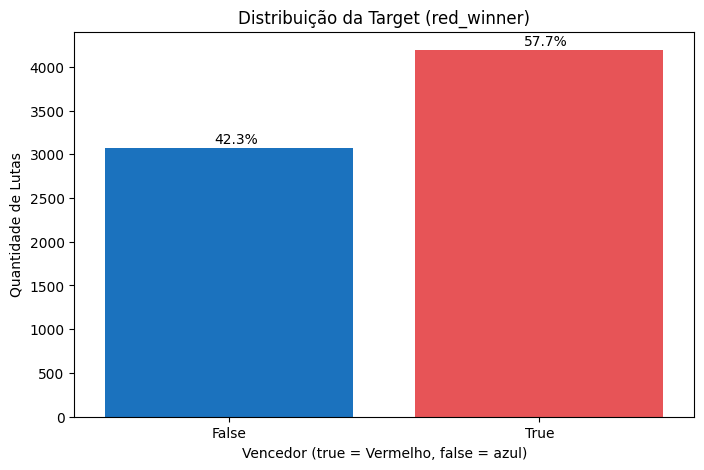

In [15]:
plt.figure(figsize=(8, 5))

#definição das cores: vermelho para "true" e azul para "false"
colors = {True: '#FF3B3F', False: '#0074D9'}
sns.countplot(data=df, x='red_winner', palette=colors, hue='red_winner', legend=False)

plt.title('Distribuição da Target (red_winner)')
plt.xlabel('Vencedor (true = Vermelho, false = azul)')
plt.ylabel('Quantidade de Lutas')

# porcetagens

total = len(df)
for p in plt.gca().patches:
  percentage = '{:.1f}%'.format(100 * p.get_height()/total)
  x = p.get_x() + p.get_width() / 2 - 0.05
  y = p.get_height() + 50
  plt.gca().annotate(percentage, (x, y))

Neste gráfico, é perceptível que o lutador do canto vermelho venceu em 57,7% das lutas, enquanto o lutador do canto azul venceu em 42,3%, resultando em um desbalanceamento entre as classes.

No entanto, esse desequilíbrio tem uma explicação contextual: no UFC, o lutador do canto vermelho costuma ser o mais bem ranqueado ou o favorito da luta, o que tende a resultar em mais vitórias para esse lado.

O dataset possui uma diferença de 15% entre os cantos, porém esse desbalanceamento não é severo o suficiente para enviesar o modelo, evitando assim a necessidade de técnicas de rebalanceamento. Além disso, pode auxiliar na tomada de decisão do modelo.

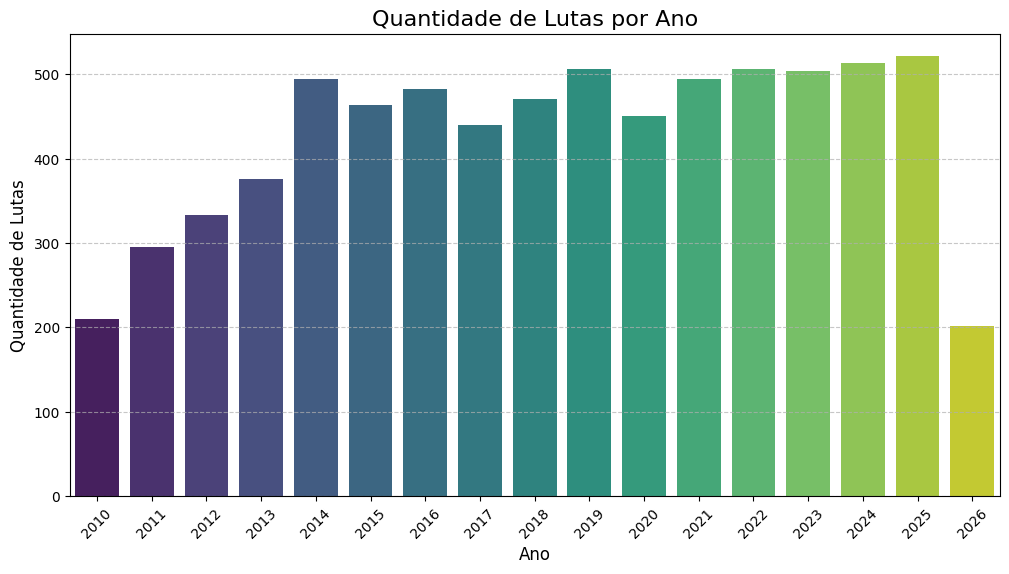

In [16]:
df['fight_date'] = pd.to_datetime(df['fight_date'])

df['year'] = df['fight_date'].dt.year

fights_per_year = df.groupby('year').size().reset_index(name='count')

#gráfico
plt.figure(figsize=(12, 6))
sns.barplot(data=fights_per_year, x='year', y='count', palette='viridis')
plt.title('Quantidade de Lutas por Ano', fontsize=16)
plt.xlabel('Ano', fontsize=12)
plt.ylabel('Quantidade de Lutas', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

No gráfico, é possível observar um crescimento consistente no número de lutas entre 2010 e 2014. A partir desse ano, o volume se estabilizou em torno de 460 a 520 lutas por ano, com pequenas variações, indicando que o UFC atingiu uma maturidade operacional nesse patamar.

Além disso, em 2020 é apresentada uma leve queda em relação aos outros anos, o que pode ser associado às restrições impostas pela pandemia de COVID-19, que afetou o mundo em razão do isolamento social.

Por fim, como o dataset coletou dados apenas até abril de 2026, o ano ainda não está completo, o que é importante considerar para evitar interpretações equivocadas de queda de atividade da organização.

In [17]:
print('\nAnálise das Idades:')
display(df[['red_age', 'blue_age']].describe())


Análise das Idades:


,red_age,blue_age
count,7265.000000,7265.000000
mean,30.512595,29.929250
std,4.201772,3.957887
min,18.000000,19.000000
25%,28.000000,27.000000
50%,30.000000,30.000000
75%,33.000000,33.000000
max,47.000000,47.000000


Análise de Outliers das Odds


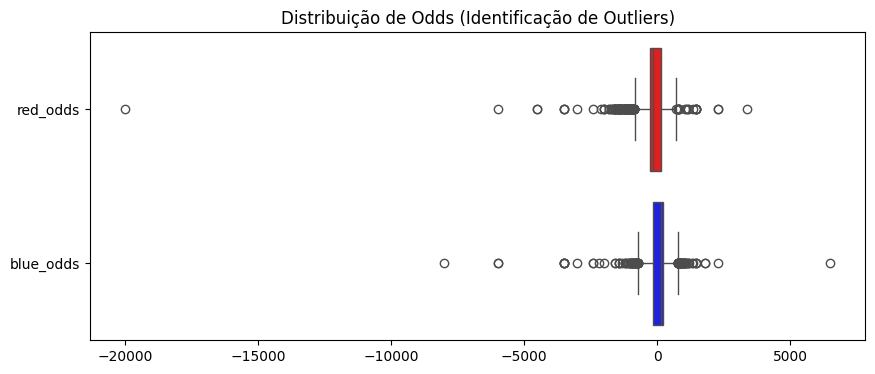

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

print('Análise de Outliers das Odds') #odds é a probabilidade de vítoria das apostas

plt.figure(figsize=(10, 4))
sns.boxplot(data=df[['red_odds', 'blue_odds']], orient='h', palette=['red', 'blue'])
plt.title('Distribuição de Odds (Identificação de Outliers)')
plt.show()

O boxplot compara as odds de apostas do canto vermelho e do canto azul. A maior parte dos valores está concentrada próxima de zero, indicando lutas equilibradas, enquanto os outliers refletem confrontos com favoritismo mais acentuado de um lutador sobre o outro.

Existe um valor extremo isolado em 'red_odds' (próximo de -20.000), muito distante dos demais outliers, sugerindo possível erro de coleta/digitação. Esse ponto merece investigação antes da modelagem.

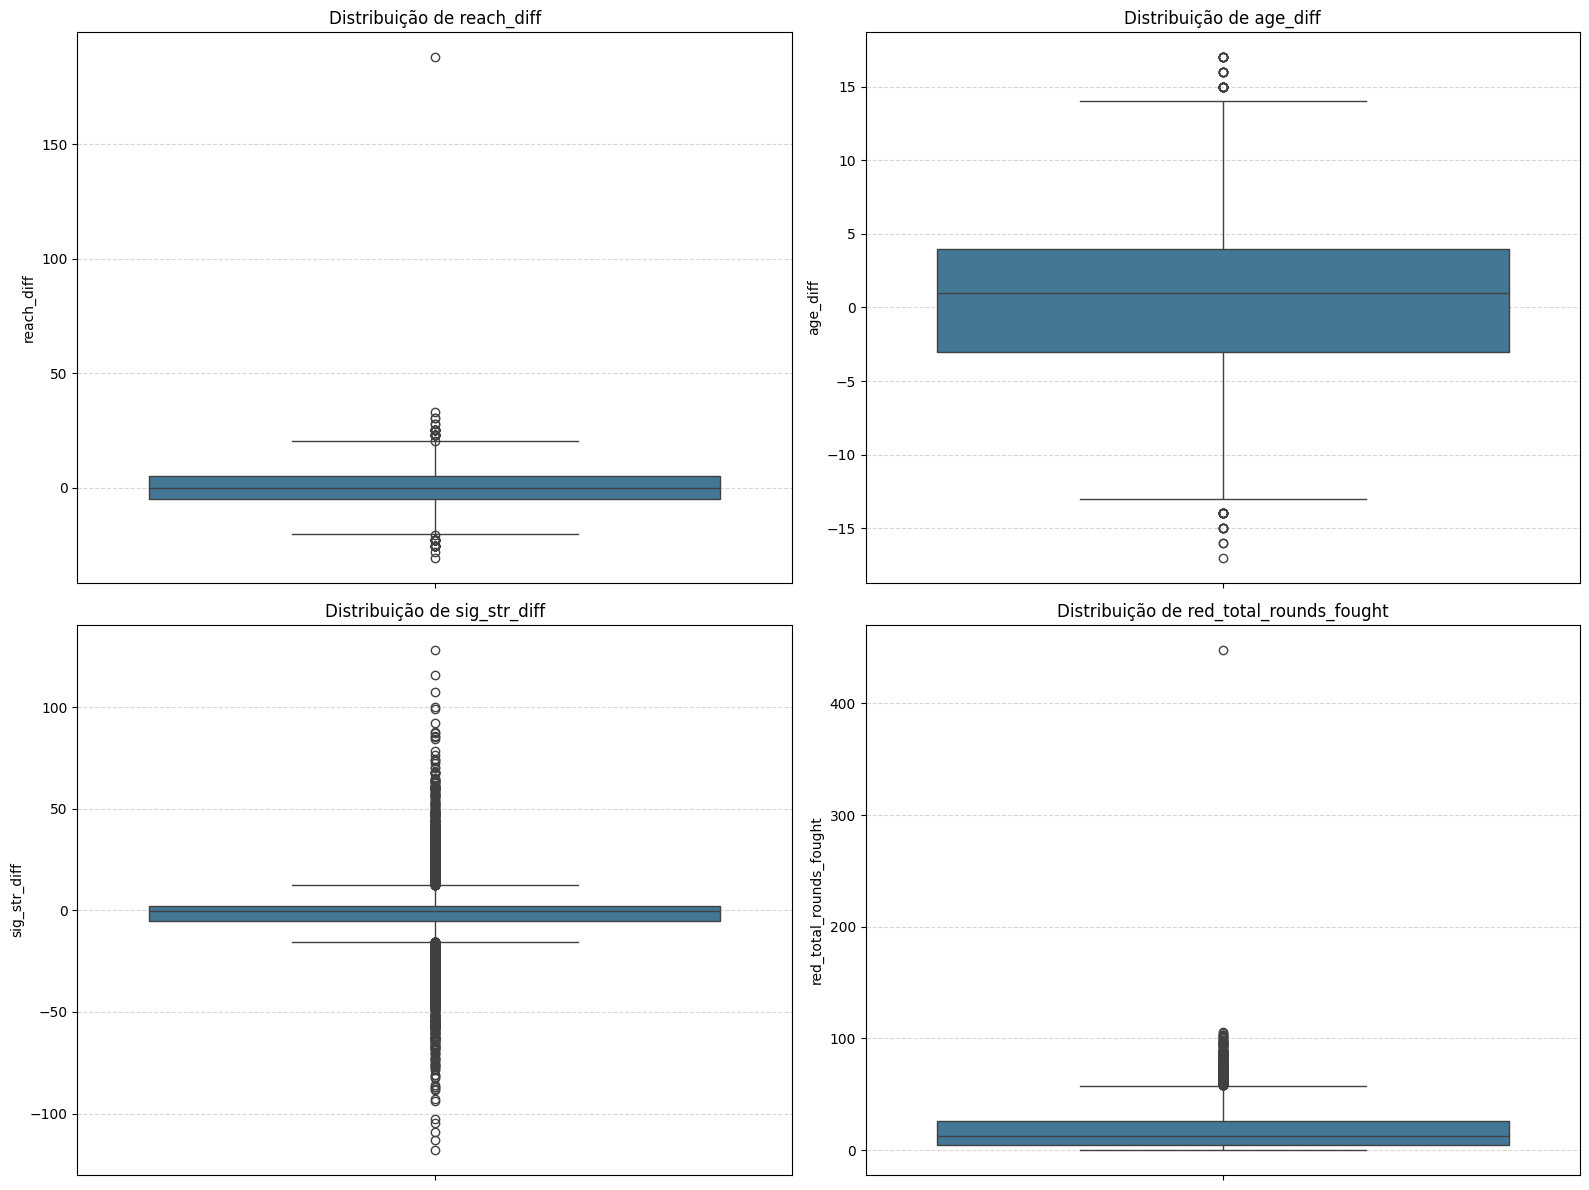

In [19]:
important_cols = ['reach_diff', 'age_diff', 'sig_str_diff', 'red_total_rounds_fought']

plt.figure(figsize=(16, 12))

for i, col in enumerate(important_cols, 1):
  plt.subplot(2, 2, i)
  sns.boxplot(y=df[col], palette='mako')
  plt.title(f'Distribuição de {col}')
  plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

As quatros variáveis apresentam a maioria dos valores concentrada próxima de zero, com outliers em diferentes graus.

'reach_diff' e 'red_total_rounds_fought' possuem outliers extremos e isolados (alcance próximo de 190 e rounds próximo de 450) que se distanciam significativamente dos demais, sugerindo possíveis erros de coleta por possuírem dados fisicamente inviáveis.

Já 'age_diff' e 'sig_str_diff' apresentam outliers mais esperados e coerentes com a variabilidade natural do esporte, não indicando necessariamente erros de dado

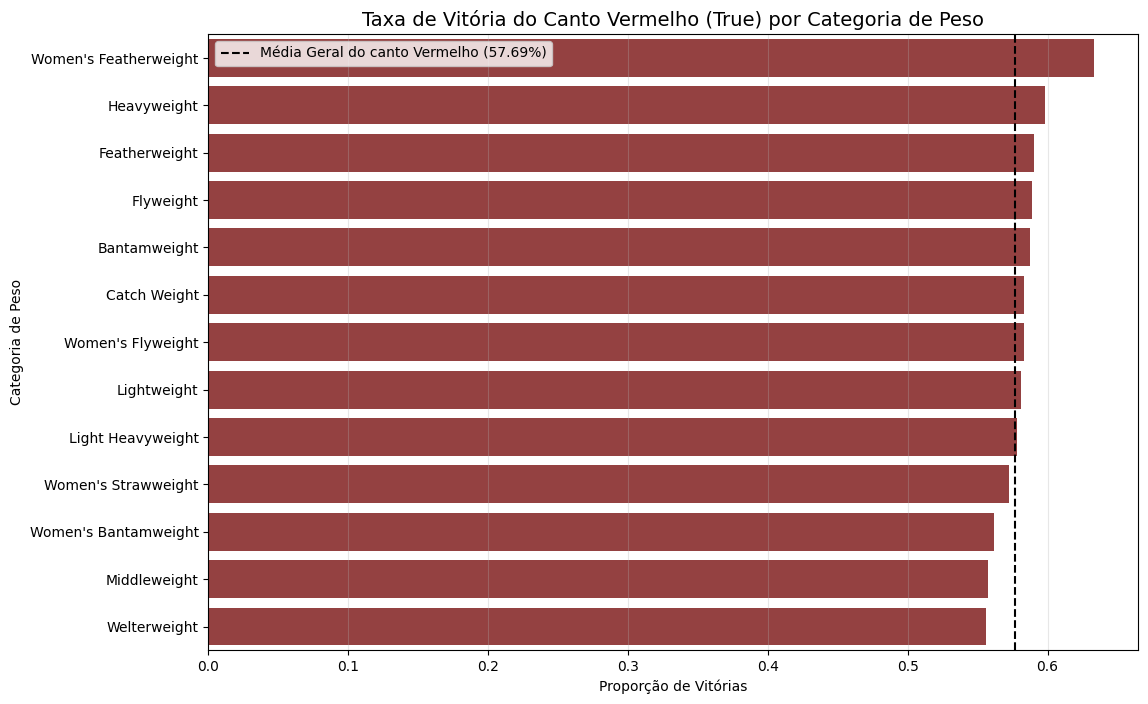

In [20]:
wc_analysis = df.groupby('weight_class')['red_winner'].value_counts(normalize=True).unstack().fillna(0)

if True in wc_analysis.columns:
  wc_analysis = wc_analysis.sort_values(by=True, ascending=False)

  plt.figure(figsize=(12, 8))
  sns.barplot(x=wc_analysis[True], y=wc_analysis.index, color='darkred', alpha=0.8)

  avg_red_win = df['red_winner'].mean()
  plt.axvline(x=avg_red_win, color='black', linestyle='--', label=f'Média Geral do canto Vermelho ({avg_red_win:.2%})')

  plt.title('Taxa de Vitória do Canto Vermelho (True) por Categoria de Peso', fontsize=14)
  plt.xlabel('Proporção de Vitórias')
  plt.ylabel('Categoria de Peso')
  plt.legend()
  plt.grid(axis='x', alpha=0.3)
  plt.show()

else:
  print(f'Valores encontrados na coluna red_winenr: {df['red_winner'].unique}')


A taxa de vitórias do canto vermelho por categoria de peso reforça um padrão já observado anteriormente: o canto vermelho, por ser atribuído ao lutador mais bem ranqueado, tende a vencer com mais frequência independentemente da categoria. Com isso, o resultado mais notável do gráfico é que todas as categorias apresentam taxa de vitória do canto vermelho acima de 50%.

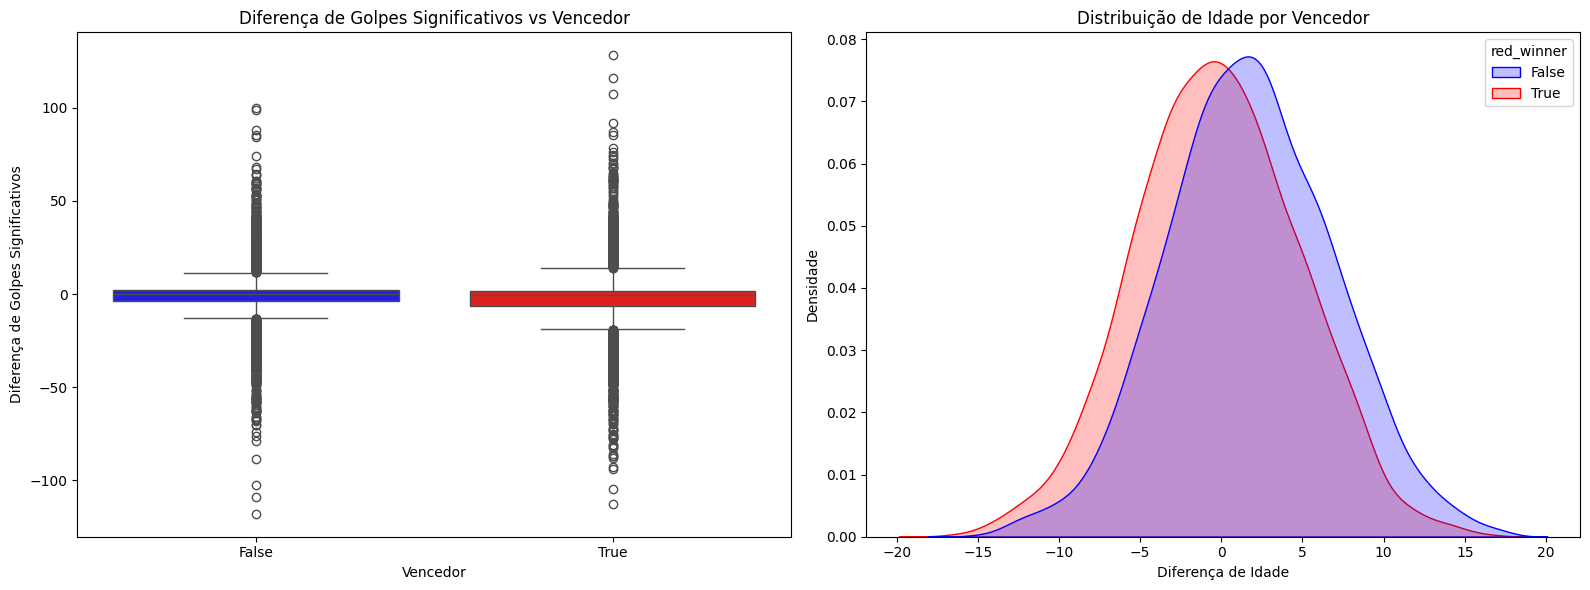

In [21]:
plt.figure(figsize=(16, 6))

df['red_winner'] = df['red_winner'].astype(bool)

#gráfico 1
plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='red_winner', y='sig_str_diff', hue='red_winner', palette={True: 'red', False: 'blue'}, legend=False)
plt.title('Diferença de Golpes Significativos vs Vencedor')
plt.xlabel('Vencedor')
plt.ylabel('Diferença de Golpes Significativos')

#gráfico 2
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='age_diff', hue='red_winner', fill=True, palette={True: 'red', False: 'blue'}, common_norm=False)

plt.title('Distribuição de Idade por Vencedor')
plt.xlabel('Diferença de Idade')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

As variáveis apresentadas no gráfico acima não possuem muita diferença entre si. No primeiro gráfico, é perceptível a presença de muitos outliers, provavelmente provenientes de lutas finalizadas por nocaute. Já no segundo gráfico, as distribuições são semelhantes, com um leve pico à esquerda para a classe True (canto vermelho).

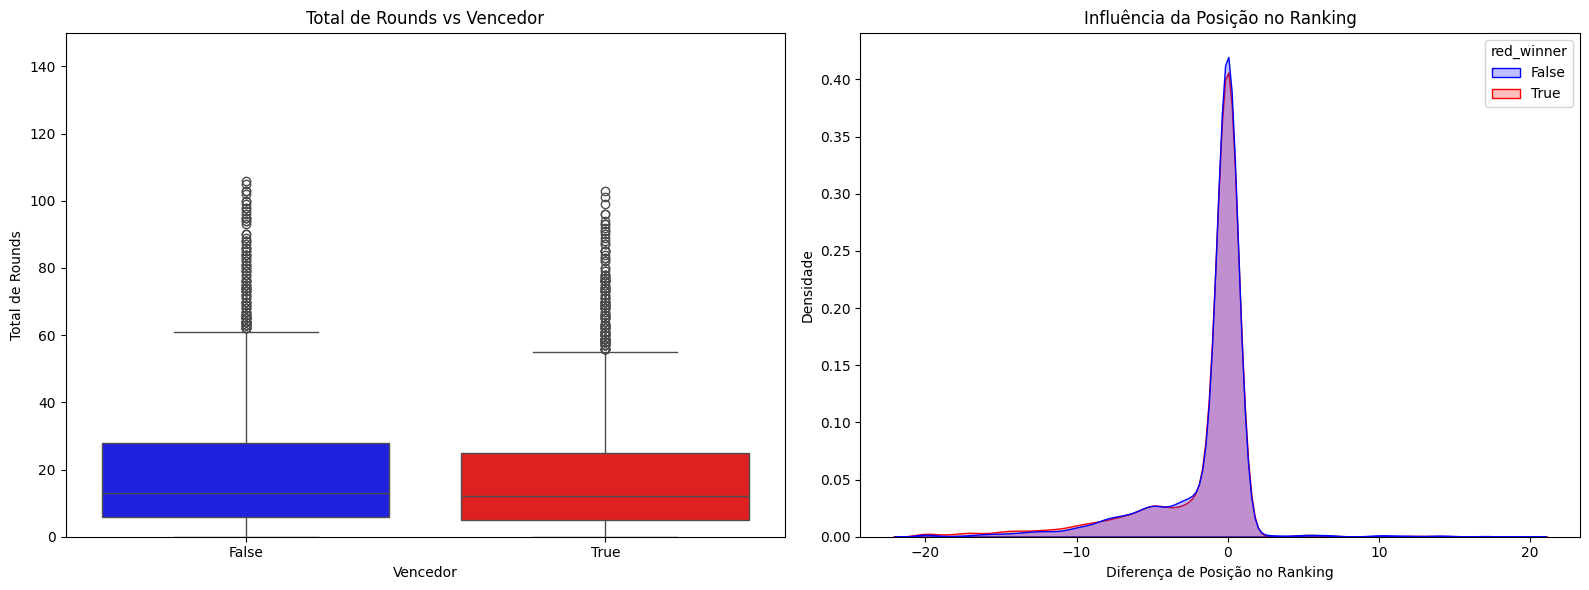

In [22]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='red_winner', y='red_total_rounds_fought', hue='red_winner', palette={True: 'red', False: 'blue'}, legend=False)
plt.title('Total de Rounds vs Vencedor')
plt.xlabel('Vencedor')
plt.ylabel('Total de Rounds')
plt.ylim(0, 150)

#gráfico2
plt.subplot(1, 2, 2)
sns.kdeplot(data=df, x='rank_diff', hue='red_winner', fill=True, palette={True: 'red', False: 'blue'}, common_norm=False)
plt.title('Influência da Posição no Ranking')
plt.xlabel('Diferença de Posição no Ranking')
plt.ylabel('Densidade')

plt.tight_layout()
plt.show()

Assim como nos gráficos anteriores, essas duas variáveis não mostram diferença perceptível entre as classes de vencedor.

In [ ]:
fig = px.scatter(df,
                 x='red_odds',
                 y='blue_odds',
                 color='red_winner',
                 color_discrete_map={True: 'red', False: 'blue'},
                 title='Apostas: Favoritismo vs Vitória Real',
                 labels={'red_odds': 'Aposta do canto Vermelho', 'blue_odds': 'Aposta do canto Azul', 'red_winner': 'Vencedor'},
                 opacity=0.5,
                 hover_data=['red_fighter', 'blue_fighter'])

fig.add_hline(y=0, line_dash="dash", line_color="black")
fig.add_vline(x=0, line_dash="dash", line_color="black")

fig.update_layout(template='plotly_white')
fig.show()

O gráfico mostra que os pontos vermelhos (vitória do canto vermelho) e azuis (vitória do canto azul) formam uma separação quase perfeita conforme o valor da aposta, confirmando que a variável de retorno da aposta tem relação direta com o resultado da luta. Isso reforça o motivo pelo qual essas colunas foram removidas do modelo, já que caracterizam vazamento de dados.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_data = df[numeric_cols].copy()
corr_data['target'] = df['red_winner'].astype(int)

correlations = corr_data.corr()['target'].sort_values(ascending=False)
top_correlations = pd.concat([correlations.head(10), correlations.tail(10)]).drop_duplicates().sort_values()

plt.figure(figsize=(10, 8))
sns.barplot(x=top_correlations.values, y=top_correlations.index, palette='RdBu_r')
plt.title('Variáveis Correlacionadas com a Vitória do canto Vermelho', fontsize=14)
plt.xlabel('Coeficiente de Correlação')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

As variáveis 'red_return' e 'blue_return' apresentam correlação muito alta com o target, o que reforça o motivo de serem removidas do modelo. As demais variáveis, como 'odds_diff', 'red_odds' e 'age_diff', mostram correlação fraca a moderada, enquanto as outras variáveis indicam pouca relação individual com a vitória do canto vermelho.

## 4.1 Síntese da análise exploratória

* O target está balanceado?

O target não está completamente balanceado. O canto vermelho vence em 57,7% das lutas contra 42,3% do canto azul, uma diferença de 15 pontos percentuais. O desbalanceamento é moderado e não exige técnicas de rebalanceamento, mas justifica o uso do F1-score como métrica principal em vez da acurácia.

* Existem valores ausentes relevantes?

Não existem valores ausentes relevantes. O dataset não apresenta nenhum valor ausente em nenhuma das 57 colunas, o que elimina a necessidade de imputação de dados.

* Há variáveis com escala muito diferente?

Há variáveis com escalas muito diferentes. As odds de apostas operam em escalas muito maiores (podendo chegar a -20.000) do que variáveis como idade (18 a 47 anos) ou diferença de alcance. Isso indica a necessidade de normalização ou padronização antes de treinar modelos sensíveis à escala, como regressão logística.

* Há categorias raras?

Existem categorias raras. A categoria 'women's featherweight' possui volume de lutas significativamente menor em relação às demais categorias, como 'lightweight' e 'welterweight', podendo gerar instabilidade em análises segmentadas por categoria.

* Existem padrões que sugerem quais modelos podem funcionar melhor?

Os padrões identificados no dataset sugerem que as odds de apostas e o histórico de sequências de vitórias são as variáveis com maior potencial preditivo para o modelo. As demais variáveis, como diferença de idade, alcance e golpes significativos, apresentaram baixo poder discriminativo isolado, com distribuições muito semelhantes entre vencedores e perdedores.

* Existem padrões que sugerem quais modelos podem funcionar melhor?

Como as relações entre as variáveis e o resultado não são puramente lineares e envolvem interações entre múltiplos fatores, modelos como Random Forest ou Gradient Boosting tendem a capturar melhor esses padrões do que um modelo linear simples, sendo os candidatos mais promissores para a etapa de modelagem.


Dois pontos principais alteraram a estratégia com o resultado da análise:

Os outliers extremos em alcance (190) e total de rounds (450) sugerem possíveis erros de coleta, exigindo tratamento pontual antes da modelagem.
As colunas 'red_return' e 'blue_return' apresentam correlação artificialmente alta com o target por serem calculadas após o resultado da luta, caracterizando vazamento de dado (data leakage) e, portanto, devem ser removidas do conjunto de features antes do treinamento.

# 5. Preparação dos dados e divisão treino/teste

In [ ]:
#Essas colunas foram removidas antes do treino por não influenciar a tomada de decisão do modelo

cols_to_drop = ['red_return', 'blue_return', 'red_fighter', 'blue_fighter']
target_col = 'red_winner'

In [ ]:
df = df.drop(columns=list(cols_to_drop), errors='ignore')
print(f'[2] Colunas removidas ({len(cols_to_drop)}):')
for col in cols_to_drop:
  print(f' - {col}')

if 'fight_date' in df.columns:
  df['fight_date'] = pd.to_datetime(df['fight_date'])
  df['fight_year'] = df['fight_date'].dt.year
  df['fight_month'] = df['fight_date'].dt.month
  df['fight_day_of_week'] = df['fight_date'].dt.dayofweek
  df = df.drop(columns=['fight_date'])

In [ ]:
df['target'] = df[target_col].map({True: 1, False: 0})
df = df.drop(columns=[target_col])

y = df['target']
x = df.drop(columns=['target'])

print(f'\n[3] Variáveis e Target separados')
print(f'x shape: {x.shape}')
print(f'y shape: {y.shape}')
print(f'y distribuição: {y.mean():.1%} classe 1 | {1 - y.mean():.1%} classe 0')


In [ ]:
df.head()

In [ ]:
split_method = 'random'
test_start_year = 2024
test_size = 0.2     # valor de divisão
random_state = 42

if split_method == 'temporal':
  train_mask = x['fight_year'] < test_start_year
  test_mask = x['fight_year'] >= test_start_year

  x_train, y_train = x[train_mask].copy(), y[train_mask].copy()
  x_test, y_test = x[test_mask].copy(), y[test_mask].copy()

  print(f'\n[4] Split temporal (corte em {test_start_year})')
  print(f' Treino: {x_train.shape[0]} linhas ({x_train["fight_year"].min()}-{x_train["fight_year"].max()})')
  print(f' Teste: {x_test.shape[0]} linhas ({x_test["fight_year"].min()}-{x_test["fight_year"].max()})')

elif split_method == 'random':
  x_train, x_test, y_train, y_test = train_test_split(
      x, y,
      test_size=test_size,
      random_state=random_state,
      stratify=y,
  )

  print(f'\n[4] Split aleatório estratificado (test_size={test_size}, random_state={random_state})')
  print(f' Treino: {x_train.shape[0]} linhas')
  print(f' Teste: {x_test.shape[0]} linhas')

else:
  raise ValueError('Método de divisão incorreto')

In [ ]:
#validação
erros = validar_split(x_train, x_test, y_train, y_test, cols_proibidas=list(cols_to_drop), method=split_method)

print(f'\n[5] Validação de integridade (Método: {split_method})')
if erros:
  print('Falha:')
  for e in erros:
    print(f'{e}')
  raise ValueError('Validação falhou')

else:
  print('Todas as validações realizadas com sucesso')
  print(f'Sem colunas de leakage/ID')
  if split_method == 'temporal':
    print(f'Sem sobreposição temporal (treino < {test_start_year} <= teste)')
  else:
    print('Split aleatório: sobreposição temporal permitida')
  print(f'Sem valores nulos')
  print(f'Ambas as classes presentes em treino e teste')
  print(f'X e Y com mesmo número de linhas')
  print(f'Volume de teste adequado ({len(x_test)} linhas)')



In [ ]:
print('\n' + '=' * 55)
print('RESUMO')
print('=' * 55)
print(f'  X_train : {x_train.shape}')
print(f'  y_train : {y_train.shape}  (classe 1: {y_train.mean():.1%})')
print(f'  X_test  : {x_test.shape}')
print(f'  y_test  : {y_test.shape}  (classe 1: {y_test.mean():.1%})')
print('=' * 55)

## 5.1 Justificativa da divisão

* Por que usar holdout, validação cruzada ou divisão temporal?

Foi usado holdout em vez de validação cruzada, por simplicidade e por o dataset ter volume suficiente.


* A proporção treino/teste faz sentido para o tamanho do dataset?

A proporção 80/20 é adequada ao tamanho do dataset.


* Foi necessário estratificar as classes?

A estratificação foi necessária no split aleatório para preservar a proporção de vitórias do canto vermelho e do canto azul em treino e teste.

* Como a divisão evita vazamento de dados?

O vazamento de dados é evitado em duas frentes: a remoção prévia de colunas de leakage ('red_return', 'blue_return') e, no modo temporal, a validação que garante que não haja sobreposição de anos entre treino e teste.

# 6. Pré-processamento: Encoding e Escalonamento

In [ ]:
#tipos de colunas
cat_features = x_train.select_dtypes(include=['object']).columns.tolist()
num_features = x_train.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

#pipelines de transformação
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

#columnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ]
)

#pipeline final
full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('selector', SelectKBest(score_func=f_classif, k=40))
])

#ajuste e transformação dos dados de treino e teste
x_train_final = full_pipeline.fit_transform(x_train, y_train)
x_test_final = full_pipeline.transform(x_test)

print(f'[6] Transformações concluídas.')
print(f'Total de variáveis originais: {x_train.shape[1]}')
print(f'Total de variáveis selecionadas: {x_train_final.shape[1]}')

In [ ]:
mask = full_pipeline.named_steps['selector'].get_support()

cat_names = full_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(cat_features)
all_names = num_features + list(cat_names)

selected_features = [name for name, selected in zip(all_names, mask) if selected]

print('Top 10 variáveis selecionadas:')
for f in selected_features[:10]:
  print(f'- {f}')

## 6.1 Decisões de pré-processamento

* Por que o uso da mediana para imputação?

Este dataset possui muitos outliers, por isso a escolha da mediana é para que não haja distorção causada pelos valores extremos.

* O dataset foi padronizado.

A padronização é usada para resolver o problema identificado na análise exploratória dos dados, de variáveis com escalas muito diferentes.

* Quais variáveis foram removidas e por quê?

Colunas excluídas: (red_fighter, blue_fighter, red_return, blue_return, fight_date)

As colunas identificadoras (red_fighter, blue_fighter) foram removidas por não acrescentarem valor à tomada de decisão do modelo. As colunas de retorno das apostas (red_return, blue_return) comprometem a validade do modelo, pois são calculadas após o resultado da luta, caracterizando vazamento de dados. Por fim, a coluna 'fight_date' foi decomposta em três novas colunas (ano, mês e dia da semana), e a coluna original sobre a data do evento foi removida.

* Criação de novas variáveis. Elas estariam disponíveis no momento real da previsão.

As variáveis criadas foram (fight_year, fight_month e fight_day_of_week) extraídas de 'fight_date'. Elas foram criadas para manter a capacidade preditiva do modelo, já que a data da luta é conhecida com antecedência e, portanto, está disponível no momento real da previsão."

# 7. Treinamento do Modelo: Baseline (Random Forest) e Candidato

In [ ]:
#baseline
rf_model = RandomForestClassifier(n_estimators=100, random_state=random_state, n_jobs=-1)
rf_model.fit(x_train_final, y_train)

#candidato
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=random_state, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(x_train_final, y_train)

print('[7] Modelos treinados com sucesso.')

## 7.1 Justificativa dos modelos

* O Random Forest é coerente como baseline por ser um modelo forte e não-linear, robusto a outliers e menos sensível a hiperparâmetros mal ajustados, servindo como referência realista de comparação.

* O XGBoost, por ser um algoritmo de gradient boosting, é adequado por capturar melhor as interações não lineares entre as variáveis, além de ser compatível com o tamanho e o formato tabular deste dataset.

* Nenhum dos dois modelos citados acima exige escalonamento, já que ambos são baseados em splits de árvores de decisão. Já o encoding é necessário para os dois modelos, pois nenhum consegue processar diretamente colunas de texto/categoria.

* A principal restrição está no custo computacional do XGBoost combinado ao GridSearchCV, que multiplica o tempo de treino devido ao número de combinações de hiperparâmetros testadas.



# 8. Avaliação Inicial Comparativa

In [ ]:
rf_acc = avaliar_modelo(rf_model, x_test_final, y_test, 'Random Forest (Baseline)')
xgb_acc = avaliar_modelo(xgb_model, x_test_final, y_test, 'XGBoost (Candidato)')

## 8.1 Análise dos resultados iniciais

* O modelo superou o baseline, com uma margem bem pequena. O XGBoost atingiu 64,90% de acurácia contra 64,35% do Random Forest, um ganho de aproximadamente 0,55 pontos percentuais, abaixo da meta de 5-10% no F1-score definida na seção 1.4.

* A métrica escolhida não é suficiente sozinha para avaliar o problema. O dataset tem desbalanceamento moderado (57,7% canto vermelho vs 42,3% canto azul), então um modelo que sempre previsse a vitória do canto vermelho já acertaria perto de 58% sem aprender nada. Por isso, o F1-score por classe é essencial para avaliar corretamente o problema, e não apenas a métrica agregada.

* O modelo não sofre de underfitting. Ao comparar treino vs teste, o Random Forest atingiu cerca de 100% de acurácia no treino contra 64,35% no teste, e o XGBoost teve 77,58% no treino contra 64,90% no teste. Ambos os casos indicam overfitting, não underfitting.

* O tempo de treino é aceitável. O Random Forest treinou em aproximadamente 1,4 segundos, e o XGBoost inicial em cerca de 0,2 segundos, ambos em ambiente local e sem necessidade de GPU. Esse resultado, é em razão do pequeno volume de dados.

* O resultado faz sentido considerando a EDA (análise exploratória de dados). As variáveis mais importantes no Random Forest foram 'odds_diff', 'red_odds' e 'blue_odds', como já havia sido identificado na análise de correlação com o target, confirmando a hipótese de que as odds de mercado carregam boa parte do sinal preditivo real. Além disso, com a remoção das variáveis de vazamento de dados, era esperado que a acurácia final ficasse moderada, em vez de artificialmente alta - o que é coerente com a imprevisibilidade do esporte.







# 9. Validação e Otimização de Hiperparâmetros

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(XGBClassifier(random_state=random_state, eval_metric='logloss'), param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)

grid_search.fit(x_train_final, y_train)

best_xgb = grid_search.best_estimator_
print(f'\nMelhores parâmetros: {grid_search.best_params_}')

#avaliação final modelo otimizado
final_acc = avaliar_modelo(best_xgb, x_test_final, y_test, 'XGBoost Otimizado')

## 9.1 Discussão da otimização

* A otimização melhorou o resultado em relação ao modelo inicial. A acurácia foi de 64,90% (XGBoost inicial) para 65,52% (XGBoost otimizado), com ganho de 0,62 pontos percentuais, também abaixo da meta de 5-10% no F1-score definida nos critérios de sucesso.

* A busca foi limitada por tempo de execução.

* Os hiperparâmetros selecionados foram: max_depth=3, learning_rate=0,01, n_estimators=200 e subsample=0,8 — uma combinação voltada à regularização, priorizando árvores rasas, passos de aprendizado pequenos e amostragem parcial dos dados.

* Se tivesse mais tempo, incluiria nas combinações o colsample_bytree, que controla as variáveis usadas por árvore, e o min_child_weight, que controla o tamanho mínimo que um "grupo" de dados precisa ter para justificar uma nova divisão (split) na árvore.


# 10. Avaliação final no conjunto de teste

In [ ]:
print(f'Acurácia Baseline: {rf_acc:.2%}')
print(f'Acurácia Otimizada: {final_acc:.2%}')
print(f'Diferença: {final_acc - rf_acc:.2%}')

y_pred_final = best_xgb.predict(x_test_final)
cm = confusion_matrix(y_test, y_pred_final)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Blue (0)', 'Red (1)']).plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusão - Modelo Final')
plt.show()

## 10.1 Análise de erros e limitações

*  O erro mais comum que o modelo comete é o falso positivo para o Canto Vermelho: o modelo prevê vitória do canto vermelho quando na verdade o azul venceu, refletindo um viés em favor do Canto Vermelho, coerente com o desbalanceamento do target (Vermelho - 57,7% vs Azul - 42,3%).

* Há sinais de overfitting, mais forte no Random Forest (treino - 100% vs teste - 64,35%) e reduzido no XGBoost otimizado (treino - 68,46% vs teste - 65,52%).

* A métrica escolhida não captura bem o objetivo do problema: olhar apenas a acurácia ou o F1-score agregado esconderia essa fragilidade específica do modelo.

* O modelo depende fortemente das odds de mercado (variáveis mais importantes), herdando qualquer viés já embutido nas casas de apostas, além do viés estrutural evidenciado na matriz, o modelo "aposta" mais no canto vermelho mesmo quando erra. Há ainda risco de generalização limitada para lutadores estreantes ou categorias de peso com poucos dados no dataset.

* Em quais cenários o modelo não deveria ser usado? Como base isolada para decisões financeiras de apostas, especialmente em lutas onde o canto azul é o favorito técnico, já que é nesse cenário que o modelo mais comete falsos positivos.

# 11. Comparação final dos modelos

In [ ]:
y_pred_rf = rf_model.predict(x_test_final)
y_pred_xgb = best_xgb.predict(x_test_final)

rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')

metrics_df = pd.DataFrame({
    'Modelo': ['Random Forest (baseline)', 'XGBoost (Otimizado)', 'Random Forest (Baseline)', 'XGBoost (Otimizado)'],
    'Métrica': ['Acurácia', 'Acurácia', 'F1-Score (Weighted)', 'F1-Score (Weighted)'],
    'Valor': [rf_acc, final_acc, rf_f1, xgb_f1]
})

#visualização
plt.figure(figsize=(10, 6))
sns.barplot(data=metrics_df, x='Métrica', y='Valor', hue='Modelo', palette='magma')

plt.ylim(0.6, 0.7)
plt.title('Comparativo Final de Performance', fontsize=14)
plt.ylabel('Score (0-1)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

for p in plt.gca().patches:
  plt.gca().annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha = 'center', va = 'center',
                     xytext = (0, 9),
                     textcoords = 'offset points')

plt.show()

print(f'Ganho de Acurácia: {final_acc - rf_acc:.2%}')
print(f'Ganho de F1-Score: {xgb_f1 - rf_f1:.2%}')



# 12. Boas práticas e rastreabilidade

| Decisão | Descrição | Impacto Esperado |
| :--- | :--- | :--- |
| **Semente (Seed)** | 42 utilizada globalmente. | Garantir que qualquer pessoa que execute o código obtenha os mesmos resultados exatos. |
| **Data Leakage** | Remoção de red_return e blue_return. | Impedir que o modelo use informações do 'futuro', evitando uma acurácia artificialmente alta e irrealista. |
| **Feature Engineering** | Decomposição de datas e cálculo de diferenciais físicos. | Capturar padrões sazonais e o impacto relativo de atributos (ex: quem é mais jovem ou tem maior alcance). |
| **Transformações** | StandardScaler e OneHotEncoder. | Garantir que o modelo trate variáveis de escalas diferentes (odds vs idade) sem viés matemático. |
| **Seleção de Features** | SelectKBest (40 melhores variáveis). | Reduzir o ruído e o custo computacional, focando apenas no que realmente explica a vitória. |
| **Modelagem** | Comparação RF vs XGBoost. | Validar se um modelo de Gradient Boosting supera a baseline de florestas aleatórias. |
| **Otimização** | GridSearchCV no XGBoost. | Encontrar o ajuste fino dos parâmetros para maximizar o F1-Score sem causar overfitting. |
| **Divisão de Dados** | train_test_split estratificado. | Garantir que a proporção de vitórias/derrotas seja a mesma no treino e no teste, evitando viés de amostragem. |
| **Limitações** | Dependência de Odds de mercado. | Reconhecer que o modelo pode herdar preconceitos ou erros de avaliação das próprias casas de apostas. |

# 13. Conclusão

* Objetivo do trabalho:

O objetivo deste MVP foi construir um modelo de classificação capaz de prever o vencedor de lutas de UFC (canto vermelho ou azul) com base em variáveis conhecidas antes do confronto,características físicas, histórico de carreira e odds de mercado, testando a hipótese de que modelos não-lineares/ensemble capturam melhor as interações entre essas variáveis do que uma abordagem trivial.

* Melhor solução encontrada:

O modelo final foi um XGBoost otimizado via GridSearchCV, com os hiperparâmetros max_depth=3, learning_rate=0,01, n_estimators=200 e subsample=0,8 - uma combinação voltada à regularização. Ele atingiu 65,52% de acurácia e F1-score de 0,65 no conjunto de teste, com o menor gap entre treino e teste (68,46% vs 65,52%) entre todos os modelos avaliados, indicando a melhor capacidade de generalização do projeto.

* Comparação com baseline:

O modelo final superou o baseline (Random Forest, 64,35% de acurácia) em apenas 1,17 ponto percentual, um ganho pequeno, abaixo da meta de 5-10% no F1-score definida nos critérios de sucesso do projeto. Ainda assim, o ganho mais relevante não foi de acurácia bruta, mas de generalização: o Random Forest teve overfitting severo (100% treino vs 64,35% teste), enquanto o XGBoost otimizado reduziu drasticamente essa diferença (3 pontos de gap, contra 13 pontos do XGBoost sem otimização).

Principais aprendizados:

* As variáveis de odds de mercado (odds_diff, red_odds, blue_odds) carregam a maior parte do sinal preditivo real, confirmando a hipótese de que o mercado de apostas já embute boa parte da informação relevante sobre o confronto.
* Colunas de retorno de aposta (red_return, blue_return) e identificadores de lutador precisaram ser removidas por vazamento de dados, um lembrete de que correlação alta com o target nem sempre significa "boa feature", às vezes significa "a resposta disfarçada".
* Ganhos de otimização de hiperparâmetros tendem a ser marginais quando o problema tem um componente forte de imprevisibilidade, nesses casos, o hiperparâmetro certo ajuda a generalizar melhor, mas não "destrava" um salto de performance.
* A acurácia agregada pode esconder desempenhos bem desiguais entre classes, nesse projeto, o modelo é consideravelmente mais confiável prevendo vitórias do canto vermelho (recall 78%) do que do azul (recall 48%).

Limitações:

* Desempenho desigual entre classes, com fragilidade real na detecção de vitórias do canto azul.
* Forte dependência das odds de mercado, o que torna o modelo, na prática, um "amplificador" da opinião das casas de apostas, mais do que uma avaliação técnica independente.
* Poucos dados para categorias de peso específicas e para lutadores estreantes, limitando a confiabilidade do modelo nesses casos.
* Teto de performance aparentemente limitado pela imprevisibilidade natural do esporte, não pela escolha do algoritmo.

Próximos passos:

* Testar RandomizedSearchCV ou Optuna com um grid mais amplo (incluindo colsample_bytree e min_child_weight) para explorar melhor o espaço de regularização.
* Investigar técnicas específicas para lidar com o desbalanceamento entre classes (ex: class_weight, oversampling/SMOTE), visando melhorar especificamente o recall da classe minoritária (Blue).
* Buscar variáveis adicionais não presentes no dataset atual (como por exemplo: dados de preparação física, lesões recentes, mudança de equipe técnica) que possam agregar sinal além do que já é capturado pelas odds de mercado.
* Avaliar o modelo separadamente por categoria de peso, para identificar se o desempenho varia significativamente entre categorias com mais ou menos dados disponíveis.